# 🚧 Notebook 09 — Putting on Guardrails
### Proximal Policy Optimization (PPO)

**Series**: RL Notebook Series · Act III — Policy-Based Methods · Post 9 of 15

---

## The Danger of Massive Leaps

In Notebook 08 (Actor-Critic), we solved the variance problem using the Advantage function. But we uncovered a new, extremely dangerous problem: **Policy Collapse.**

If the Critic gave the Actor a massive Advantage score, the Actor would take a massive mathematical step during Backpropagation. That huge gradient step would irreversibly scramble the neural network's weights, instantly causing the agent to forget everything it had learned and plummeting its score back down to zero.

Think of a neural network walking blindfolded through a minefield. 
- If it takes slow, 1-inch shuffles, it will eventually find the safe path to the goal.
- If it takes random 10-foot leaps, it *might* survive once, but eventually, it will land on a mine and blow up its own policy.

## Trust Regions & PPO

We need a mathematical guarantee that the Actor is **never allowed to take a massive leap**, regardless of how good the Advantage score is.

We define a **Trust Region**: Before we update our policy, we draw a small boundary around our current state. We promise that our newly updated policy will not step outside that boundary. 

**Proximal Policy Optimization (PPO)** does this using an incredibly elegant trick called the **Clipped Surrogate Objective**. It is the absolute industry standard RL algorithm powering modern AI, from OpenAI's Dota bots to ChatGPT's RLHF tuning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3})

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. The Ratio and the Clip

Instead of updating the probabilities directly with `-log_prob * Advantage` like we did in REINFORCE/A2C, PPO calculates the **Ratio** between the *new* policy we are currently updating, and the *old* policy that originally played the episode.

$$ r_t(\theta) = \frac{\pi_{\text{new}}(a|s)}{\pi_{\text{old}}(a|s)} $$

If $r_t > 1$, the action is more probable now than it was before.

### The Magic Trick
We multiply that ratio by our Advantage... but we use `torch.clamp` to restrict the ratio between `0.8` and `1.2` (an epsilon $\epsilon = 0.2$).

Let's say an action was shockingly good (Positive Advantage). PPO pushes the probability of taking that action up... but once it has increased by `20%` compared to the old policy, **PPO stops rewarding the network.** The gradient hits zero. It restricts the neural network from taking a gigantic leap of faith, completely preventing Policy Collapses.

In [2]:
class PPOActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(PPOActorCritic, self).__init__()
        # The shared body
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        
        # The Actor Head
        self.actor_fc = nn.Linear(hidden_dim, action_dim)
        
        # The Critic Head
        self.critic_fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, state):
        x = torch.tanh(self.fc1(state))
        action_logits = self.actor_fc(x)
        action_probs = F.softmax(action_logits, dim=-1)
        state_value = self.critic_fc(x)
        
        return action_probs, state_value
    
    def evaluate(self, state, action):
        """Used during the PPO update loop to get the new log_probs and values"""
        action_probs, state_value = self.forward(state)
        m = Categorical(action_probs)
        # Get the new log probability of the action we took in the past
        log_prob = m.log_prob(action)
        entropy = m.entropy()
        return log_prob, state_value, entropy

## 2. Sample Efficiency through Epochs

Because PPO mathematically prevents the policy from moving too far, we can safely reuse the same batch of data multiple times! 

In A2C, we played an episode, did one single backpropagation pass, and threw the data away. 
In PPO, we play an episode, save everything into memory, and then run **Epochs** (e.g., updating our neural network 4 or 5 times using the *exact same experience data*).

In [3]:
class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []
        
    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.log_probs.clear()
        self.rewards.clear()
        self.values.clear()
        self.dones.clear()

## 2b. Generalized Advantage Estimation (GAE)

In Notebook 08, we used a simple advantage: $A_t = G_t - V(s_t)$.
But this has a problem — Monte Carlo returns ($G_t$) are **high variance**.

There's a better way: **GAE** (Generalized Advantage Estimation).

First, compute the **TD error** at each step:

$$\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

Then, GAE is a **decayed sum of future TD errors**:

$$\hat{A}_t^{GAE} = \delta_t + (\gamma\lambda)\delta_{t+1} + (\gamma\lambda)^2\delta_{t+2} + \cdots$$

The parameter $\lambda$ controls the **bias-variance tradeoff**:
- $\lambda = 0$: Just the 1-step TD error (low variance, high bias)
- $\lambda = 1$: Full Monte Carlo return (high variance, low bias)
- $\lambda = 0.95$: The sweet spot used by virtually all modern PPO implementations

GAE is computed efficiently in a single backward pass (see the training loop below).

## 3. The PPO Training Loop

Inside our update function, we will:
1. Convert our RolloutBuffer history into PyTorch Tensors.
2. Calculate the real Returns (just like we did in Notebook 08).
3. Loop `K_epochs` times. In each epoch, calculate the new Ratio.
4. Apply the `torch.clamp` math to restrict the Actor's update.

In [4]:
def train_ppo(env_name='CartPole-v1', num_episodes=500, gamma=0.99, gae_lambda=0.95, lr=1e-3, K_epochs=4, eps_clip=0.2):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    network = PPOActorCritic(state_dim, action_dim)
    optimizer = optim.Adam(network.parameters(), lr=lr)
    memory = RolloutBuffer()
    
    episode_rewards = []
    update_interval = 4
    ep_count = 0
    
    for ep in range(num_episodes):
        state, _ = env.reset()
        done = False
        truncated = False
        ep_reward = 0
        
        # 1. Collect Trajectory (The "Old" Policy)
        while not (done or truncated):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                action_probs, value = network(state_tensor)
            
            m = Categorical(action_probs)
            action = m.sample()
            log_prob = m.log_prob(action)
            
            next_state, reward, done, truncated, _ = env.step(action.item())
            
            # Store experience in memory
            memory.states.append(state)
            memory.actions.append(action.item())
            memory.log_probs.append(log_prob.item())
            memory.values.append(value.item())
            memory.rewards.append(reward)
            memory.dones.append(done or truncated)
            
            state = next_state
            ep_reward += reward
            
        episode_rewards.append(ep_reward)
        ep_count += 1
        
        # 2. Convert memory to tensors
        if ep_count % update_interval == 0:
            old_states = torch.FloatTensor(np.array(memory.states))
            old_actions = torch.LongTensor(np.array(memory.actions))
            old_log_probs = torch.FloatTensor(np.array(memory.log_probs))
            old_values = torch.FloatTensor(np.array(memory.values))
            
            # Calculate Advantages using GAE (Generalized Advantage Estimation)
            # Instead of using simple Monte Carlo returns (G_t - V(s)),
            # GAE blends 1-step and multi-step TD errors using lambda.
            rewards = torch.FloatTensor(memory.rewards)
            dones = torch.FloatTensor(memory.dones)
            
            advantages = torch.zeros_like(rewards)
            gae = 0
            for t in reversed(range(len(rewards))):
                if t == len(rewards) - 1:
                    next_value = 0  # Terminal
                else:
                    next_value = old_values[t + 1]
                
                # If episode ended, next_value should be 0
                next_value = next_value * (1 - dones[t])
                
                # TD error: δ_t = r_t + γ*V(s_{t+1}) - V(s_t)
                delta = rewards[t] + gamma * next_value - old_values[t]
                
                # GAE: Â_t = δ_t + γλ*Â_{t+1}  (decayed sum of future TD errors)
                gae = delta + gamma * gae_lambda * (1 - dones[t]) * gae
                advantages[t] = gae
            
            # Returns = Advantages + Values (for critic target)
            returns = advantages + old_values
            
            # Normalize advantages (standard practice for stable training)
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            
            # 3. PPO Update (Train K_epochs on the same data!)
            for _ in range(K_epochs):
                # Evaluate the old actions using the NEW currently-updating policy
                new_log_probs, new_values, entropy = network.evaluate(old_states, old_actions)
                new_values = new_values.squeeze()
                
                # Calculate the Probability Ratio: pi_new / pi_old
                # Using logs: exp(log_new - log_old) is mathematically identically to (new / old)
                ratios = torch.exp(new_log_probs - old_log_probs.detach())
                
                # The Unclipped Surrogate Objective
                surr1 = ratios * advantages.detach()
                
                # The CLIPPED Surrogate Objective (The Magic Trick)
                surr2 = torch.clamp(ratios, 1 - eps_clip, 1 + eps_clip) * advantages.detach()
                
                # PPO Actor Loss: We take the MINIMUM or worst-case scenario. 
                # PPO ignores the update if the probability shifts more than 20% (eps_clip)
                actor_loss = -torch.min(surr1, surr2).mean()
                
                # Standard Critic MSE Loss
                critic_loss = 0.5 * F.mse_loss(new_values, returns.detach())
                entropy_loss = -0.01 * entropy.mean()
                
                # PPO combined Loss
                loss = actor_loss + critic_loss + entropy_loss
                
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(network.parameters(), 0.5)
                optimizer.step()
                
            # Clear memory after the K epochs are done to prepare for the next new rollout
            memory.clear()
            
        if (ep + 1) % 50 == 0:
            avg = np.mean(episode_rewards[-50:])
            print(f"Episode {ep+1:3d} | Avg Reward: {avg:.1f}")
            
    return network, episode_rewards

Episode  50 | Avg Reward: 25.2
Episode 100 | Avg Reward: 35.9
Episode 150 | Avg Reward: 53.1
Episode 200 | Avg Reward: 65.2
Episode 250 | Avg Reward: 67.3
Episode 300 | Avg Reward: 85.8
Episode 350 | Avg Reward: 66.3
Episode 400 | Avg Reward: 70.6
Episode 450 | Avg Reward: 60.8
Episode 500 | Avg Reward: 79.4


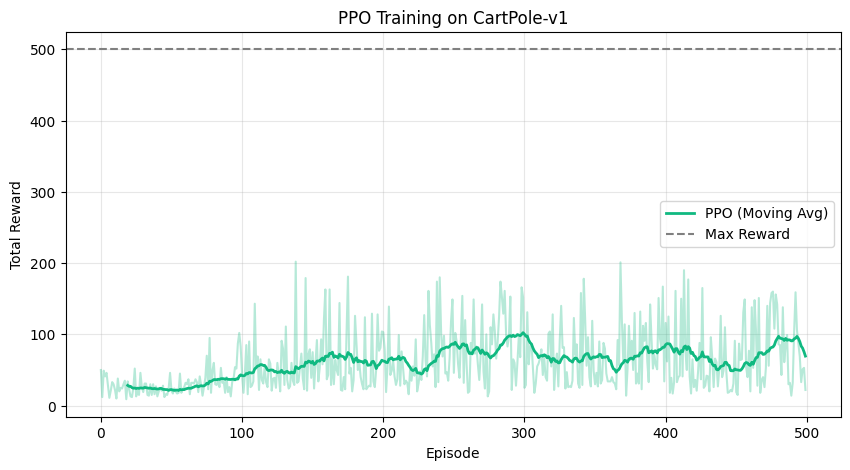

In [5]:
trained_net, ppo_rewards = train_ppo(num_episodes=500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ppo_rewards, color='#10b981', alpha=0.3)

window = 20
if len(ppo_rewards) >= window:
    smoothed = np.convolve(ppo_rewards, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, len(ppo_rewards)), smoothed, color='#10b981', linewidth=2, label=f'PPO (Moving Avg)')

ax.set_title("PPO Training on CartPole-v1")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.axhline(500, color='gray', linestyle='--', label="Max Reward")
ax.legend()
plt.show()

## 4. Watch the Agent Play!

Let's render our PPO agent.

In [6]:
def render_agent(env_name, agent):
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset(seed=42)
    frames = []
    
    done = False
    truncated = False
    while not (done or truncated) and len(frames) < 500:
        frames.append(env.render())
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            action_probs, _ = agent(state_tensor)
            action = action_probs.argmax().item() # We can safely act greedily here!
        state, _, done, truncated, _ = env.step(action)
    env.close()
    
    fig, ax = plt.subplots(figsize=(6,4))
    ax.axis('off')
    img = ax.imshow(frames[0])
    
    def animate(i):
        img.set_data(frames[i])
        return [img]
        
    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
    plt.close() # Prevent extra static plot from showing
    return HTML(anim.to_jshtml())

render_agent('CartPole-v1', trained_net)


## 5. The Entropy Bonus 🎲

You may have noticed this line in our training loop:

```python
entropy_loss = -0.01 * entropy.mean()
```

This is the **entropy bonus** — a small but crucial trick used in all production PPO implementations.

The entropy of a policy $H(\pi)$ measures how **random** its action choices are:
- **High entropy** = the agent explores many actions (good for learning)
- **Low entropy** = the agent is very confident in one action (can be premature)

$$H(\pi) = -\sum_a \pi(a|s) \log \pi(a|s)$$

By **adding** entropy to the objective (or equivalently, subtracting `−entropy` from the loss),
we **reward** the policy for maintaining some randomness. This prevents it from collapsing
to a deterministic policy too early, which would kill exploration.

| Coefficient | Effect |
| :---: | :--- |
| 0.0 | No entropy bonus — risk of premature convergence |
| 0.01 | Standard value — gentle encouragement to explore |
| 0.1+ | Very high — policy stays random, slow convergence |

The full PPO loss is therefore:

$$L = L_{actor} + c_1 L_{critic} - c_2 H(\pi)$$

where $c_1 = 0.5$ (critic weight) and $c_2 = 0.01$ (entropy coefficient) are the standard values.

## Conclusion

Look at how beautiful and stable that learning curve is! Compare it to the massive, terrifying dips in the Actor-Critic plot we saw in Notebook 08.

By adding a single `torch.clamp()` mathematical operation, PPO completely prevents the massive, chaotic gradient norms that were shattering the network. 

Furthermore, because it uses the `RolloutBuffer` safely over multiple `K_epochs`, PPO is magnitudes more sample-efficient than REINFORCE. It squeezes every drop of juice out of its experience before moving on.

You have now implemented **Proximal Policy Optimization**. The exact same algorithmic math concept inside your `train_ppo` loop is the underlying engine that trained ChatGPT and DeepMind's dexterity robotic hands!

### What's Next?
We've spent the entire tutorial playing with a discrete environment (CartPole, where you can only press button `0` or button `1`).

But what if we want to drive a car and turn the steering wheel exactly `12.5` degrees? 

In **Notebook 10**, we step entirely out of discrete actions and learn how to use Neural Networks to output **Continuous Actions**. Welcome to the domain of true Robotics.